# Project: Bayesian Optimization of Architected Structures for Energy Absorption

**MSE 238 — W2026**

---

## Background

Architected structures — 3D-printed lattices and shells with geometrically tunable features — have emerged as a promising class of materials for impact protection. Their mechanical performance (e.g., energy absorption, peak load, specific stiffness) depends on a large number of geometric design parameters, making exhaustive testing infeasible. Bayesian optimization (BO) combined with Gaussian Process Regression (GPR) provides a principled, sample-efficient framework for navigating such high-dimensional design spaces.

This project is based on the paper:

> **Snapp et al., "Autonomous Discovery of Tough Structures," *Nature Communications*, 2024.**

which we encourage you to read. In that work, a robot-assisted platform autonomously designed, fabricated, tested, and updated a surrogate model iteratively — selecting new structures to print based on an acquisition function. You will replicate the core optimization loop *in silico*, working entirely with the cleaned simulation database that was used to benchmark the autonomous system.

---

## Dataset

The file `REAL_Cleaned_Data.csv` contains **13,224 simulated structures**. Each row is one structure. The columns are:

| Column | Variable | Description |
|--------|----------|-------------|
| `x1` | `perimeter_ratio` | Ratio between top and base cross-section perimeters |
| `x2` | `c4_base` | Amplitude of the base 4-lobe cross-sectional feature |
| `x3` | `c8_base` | Amplitude of the base 8-lobe cross-sectional feature |
| `x4` | `c4_top` | Amplitude of the top 4-lobe cross-sectional feature |
| `x5` | `c8_top` | Amplitude of the top 8-lobe cross-sectional feature |
| `x6` | `twist_linear` | Linear twist from base to top (rad) |
| `x7` | `twist_amplitude` | Amplitude of oscillating twist (rad) |
| `x8` | `twist_cycles` | Number of cycles of oscillating twist |
| `x9` | `height` | Recorded structure height (mm) |
| `x10` | `mass` | Recorded structure mass (g) |
| `x11` | `wall_thickness` | Wall thickness (mm) |
| `y` | — | **Energy absorption efficiency** (dimensionless, higher is better) |

Note that `x1`–`x8` are the **design parameters** you control when specifying a geometry to print. `x9`–`x11` are **physical outcomes** measured after fabrication/simulation. Think carefully about which features are appropriate to include as inputs to your surrogate model, and justify your choice.

---

## Your Starting Points

You are given six seed measurements to begin your campaign. Their row indices in the dataset are provided below. **Do not load or inspect `y` values for any other rows before your optimization loop selects them.** Treat the rest of the dataset as an unmeasured pool — exactly as you would in a real autonomous experiment.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel, WhiteKernel

# Load the full dataset
df = pd.read_csv("REAL_Cleaned_Data.csv", index_col=0)

# ---------------------------------------------------------------
# Seed indices — these are the only rows whose y values you are
# allowed to observe at the start of your campaign.
# ---------------------------------------------------------------
SEED_INDICES = [626, 5886, 12563, 12681, 12941, 12834]

seed_df = df.loc[SEED_INDICES]
print("Seed structures:")
display(seed_df)

Seed structures:


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,y
626,0.000000,0.112968,0.395387,0.976936,0.976936,0.000000,0.000000,0.000000,19.2038,0.581272,3.36720,0.246001
5886,16.226354,0.179239,0.733291,-0.261582,-0.099049,0.137958,0.264178,0.020190,19.2592,0.836255,2.11120,0.493187
12563,0.000000,0.650194,0.650194,-0.134506,-0.134506,0.000000,0.000000,0.000000,15.6195,0.688027,1.50935,0.333179
12681,0.000000,0.443189,0.443189,-0.448725,-0.448725,0.240747,0.000000,0.000000,19.1635,0.684146,1.42790,0.363742
12941,19.636319,0.870120,0.348868,0.374745,-0.201673,0.327100,0.156843,0.026476,22.0556,0.817124,2.49010,0.513736
12834,0.000000,0.904592,0.904592,0.101134,0.101134,2.042766,0.000000,0.000000,23.9285,0.771950,2.47740,0.460410


---

## Task

Using the six seed structures above as your initial training set, implement a Bayesian optimization loop to find the structure with the **highest energy absorption efficiency** (`y`) in the dataset.

At each iteration your loop should:
1. Fit a GPR surrogate model on all currently observed structures.
2. Apply an acquisition function to the **unobserved** pool to select the next structure to evaluate.
3. "Query" that structure — look up its `y` value from the dataset.
4. Add it to your training set and repeat.

Stop when you are satisfied that you have found (or can convincingly argue you are near) the global optimum. The dataset is your oracle — you are not allowed to look ahead at `y` values outside your training set.

### Things you must address in your notebook

- **Kernel choice and optimization:** Select (briefly justify your choice) and tune a kernel. Report the optimized hyperparameters after the final fit.
- **Acquisition function:** Choose one or a combination of acquisition functions appropriate for optimization. Briefly justify your choice.
- **Visualizations:** Show the progress of your optimization. At minimum you should include a learning curve showing the best-observed `y` at each iteration. Additional plots (e.g., GPR predictions or uncertainty in reduced dimensions, iteration-by-iteration snapshots) are encouraged — choose whatever you think communicates the story of your search most clearly.
- **Stopping criteria:** State explicitly when and why you decided to stop, referring to a quantitative criterion derived from your learning curve or model uncertainty.
- **Result:** Report the best structure you found: its index, feature values, and `y`. State whether or not you believe it is the global optimum and why.

> **Reminder:** Your notebook should be self-contained and re-runnable from top to bottom. Before submitting, restart the kernel and run all cells.

---

## Rubric

| Category | Points | What we are looking for |
|----------|--------|--------------------------|
| **Optimization integrity** | 15 | The BO loop is logically sound. |
| **Acquisition function** | 23 | An acquisition function (or strategically combined acquisition functions) suited to the task is used and its choice is justified.|
| **GPR kernel choice and tuning** | 12 | The kernel is thoughtfully chosen for the structure of this problem (justify your choice). Hyperparameters are optimized. Optimization is shown.|
| **Visualization and plots** | 22 | A learning curve (best-observed `y` vs. iteration) is present and informative. Additional plots are present and meaningfully support the narrative of the search. Figures have proper axis labels, titles, and legends. |
| **Stopping criteria** | 10 | A quantitative stopping criterion is stated and justified. |
| **Result** | 7 | A global optimum has been found (not stuck in a local maxima). |
| **Discussion** | 5 | The best-found structure is reported with its index and feature values. The student argues clearly whether the global optimum has been found. |
| **Notebook quality** | 6 | Code is understandable, concise, and organized. Markdown cells and comments provide context. No unnecessary output or unnecessarily wordy explanations. |

**Total: 100 points**

---

### Submission

Submit a single `.ipynb` file with all outputs visible. 

In [14]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from sklearn.exceptions import ConvergenceWarning
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# -------------------------
# Load dataset
# -------------------------
df = pd.read_csv("REAL_Cleaned_Data.csv", index_col=0)

# -------------------------
# Required seed indices
# -------------------------
SEED_INDICES = [626, 5886, 12563, 12681, 12941, 12834]

# -------------------------
# Split features / target
# -------------------------
X = df.drop(columns="y").copy()
y = df["y"].copy()

feature_names = X.columns.tolist()

print(f"Dataset shape: {df.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Initial best seed y: {y.loc[SEED_INDICES].max():.6f}")

display(df.loc[SEED_INDICES])

Dataset shape: (13224, 12)
Number of features: 11
Initial best seed y: 0.513736


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,y
626,0.000000,0.112968,0.395387,0.976936,0.976936,0.000000,0.000000,0.000000,19.2038,0.581272,3.36720,0.246001
5886,16.226354,0.179239,0.733291,-0.261582,-0.099049,0.137958,0.264178,0.020190,19.2592,0.836255,2.11120,0.493187
12563,0.000000,0.650194,0.650194,-0.134506,-0.134506,0.000000,0.000000,0.000000,15.6195,0.688027,1.50935,0.333179
12681,0.000000,0.443189,0.443189,-0.448725,-0.448725,0.240747,0.000000,0.000000,19.1635,0.684146,1.42790,0.363742
12941,19.636319,0.870120,0.348868,0.374745,-0.201673,0.327100,0.156843,0.026476,22.0556,0.817124,2.49010,0.513736
12834,0.000000,0.904592,0.904592,0.101134,0.101134,2.042766,0.000000,0.000000,23.9285,0.771950,2.47740,0.460410


In [15]:
# -------------------------
# Standardize X for GPR
# -------------------------
x_scaler = StandardScaler()
X_scaled = pd.DataFrame(
  x_scaler.fit_transform(X),
  index=X.index,
  columns=X.columns
)

# -------------------------
# Expected Improvement
# -------------------------
def expected_improvement(mu, sigma, best_y, xi=0.01):
  mu = np.asarray(mu)
  sigma = np.asarray(sigma)

  ei = np.zeros_like(mu, dtype=float)
  mask = sigma > 1e-12

  improvement = mu[mask] - best_y - xi
  z = improvement / sigma[mask]

  ei[mask] = improvement * norm.cdf(z) + sigma[mask] * norm.pdf(z)
  return ei

# -------------------------
# Mixed EI + random damping term
# acquisition = EI + random_weight * sigma * U(0,1)
# -------------------------
def mixed_ei_acquisition(mu, sigma, best_y, rng, xi=0.01, random_weight=0.10):
  ei = expected_improvement(mu, sigma, best_y, xi=xi)
  random_draw = rng.random(len(mu))
  random_bonus = random_weight * sigma * random_draw
  acquisition = ei + random_bonus
  return acquisition, ei, random_bonus, random_draw

In [16]:
def make_gp(random_state=238):
  kernel = (
    ConstantKernel(1.0, (1e-2, 1e2))
    * Matern(
      length_scale=np.ones(X.shape[1]),
      length_scale_bounds=(1e-1, 1e2),
      nu=1.5
    )
    + WhiteKernel(
      noise_level=1e-6,
      noise_level_bounds=(1e-8, 1e-3)
    )
  )

  gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=0,
    random_state=random_state
  )
  return gp

In [17]:
def run_bayesian_optimization(
  X_scaled,
  y,
  seed_indices,
  n_iter=60,
  xi=0.01,
  random_weight=0.10,
  random_state=238,
  patience=15,
  sigma_tol=0.035
):
  rng = np.random.default_rng(random_state)

  observed = list(seed_indices)
  unobserved = list(X_scaled.index.difference(observed))

  gp = make_gp(random_state=random_state)

  history = []
  no_improve_streak = 0

  best_so_far = float(y.loc[observed].max())

  for it in range(1, n_iter + 1):
    # fit surrogate on observed data only
    X_train = X_scaled.loc[observed].values
    y_train = y.loc[observed].values
    gp.fit(X_train, y_train)

    # predict on unseen pool
    X_pool = X_scaled.loc[unobserved].values
    mu_pool, sigma_pool = gp.predict(X_pool, return_std=True)

    current_best = float(y.loc[observed].max())

    acquisition, ei_pool, rand_bonus_pool, rand_draw_pool = mixed_ei_acquisition(
      mu=mu_pool,
      sigma=sigma_pool,
      best_y=current_best,
      rng=rng,
      xi=xi,
      random_weight=random_weight
    )

    # pick next query
    j = int(np.argmax(acquisition))
    next_idx = unobserved[j]
    next_y = float(y.loc[next_idx])

    improved = next_y > current_best
    if improved:
      no_improve_streak = 0
    else:
      no_improve_streak += 1

    observed.append(next_idx)
    unobserved.pop(j)

    best_so_far = max(best_so_far, next_y)
    mean_top10_sigma = float(np.mean(np.sort(sigma_pool)[-10:]))

    history.append({
      "iteration": it,
      "selected_index": int(next_idx),
      "selected_y": next_y,
      "best_observed_y": best_so_far,
      "current_best_before_query": current_best,
      "pred_mu_selected": float(mu_pool[j]),
      "pred_sigma_selected": float(sigma_pool[j]),
      "ei_selected": float(ei_pool[j]),
      "random_bonus_selected": float(rand_bonus_pool[j]),
      "random_draw_selected": float(rand_draw_pool[j]),
      "acq_selected": float(acquisition[j]),
      "improved": improved,
      "no_improve_streak": no_improve_streak,
      "mean_top10_sigma_pool": mean_top10_sigma,
      "n_observed": len(observed)
    })

    # quantitative stopping rule
    if (no_improve_streak >= patience) and (mean_top10_sigma < sigma_tol):
      print(f"Stopped at iteration {it}: no improvement for {patience} steps and low top-pool uncertainty.")
      break

  history_df = pd.DataFrame(history)

  # final refit on all observed points
  gp.fit(X_scaled.loc[observed].values, y.loc[observed].values)

  return history_df, observed, unobserved, gp

In [18]:
# -------------------------
# Tunable acquisition knobs
# -------------------------
XI = 0.01
RANDOM_WEIGHT = 0.10
MAX_ITERS = 60

history_df, observed_indices, unobserved_indices, gp_final = run_bayesian_optimization(
  X_scaled=X_scaled,
  y=y,
  seed_indices=SEED_INDICES,
  n_iter=MAX_ITERS,
  xi=XI,
  random_weight=RANDOM_WEIGHT,
  random_state=238,
  patience=15,
  sigma_tol=0.035
)

print(f"Iterations completed: {len(history_df)}")
print(f"Best observed y: {history_df['best_observed_y'].max():.6f}")
print(f"Best selected index during BO: {int(history_df.loc[history_df['best_observed_y'].idxmax(), 'selected_index'])}")

display(history_df.head())
display(history_df.tail())

Iterations completed: 60
Best observed y: 0.715717
Best selected index during BO: 10050


,iteration,selected_index,selected_y,best_observed_y,current_best_before_query,pred_mu_selected,pred_sigma_selected,ei_selected,random_bonus_selected,random_draw_selected,acq_selected,improved,no_improve_streak,mean_top10_sigma_pool,n_observed
0,1,13069,0.358045,0.513736,0.513736,0.559235,0.104714,0.061902,0.002769,0.264470,0.064672,False,1,0.096694,7
1,2,6903,0.279528,0.513736,0.513736,0.481342,0.060740,0.008708,0.005598,0.921690,0.014307,False,2,0.088926,8
2,3,6942,0.601266,0.601266,0.513736,0.453004,0.074240,0.006762,0.006700,0.902424,0.013462,True,0,0.097721,9
3,4,801,0.184200,0.601266,0.601266,0.498906,0.120130,0.011304,0.010744,0.894344,0.022047,False,1,0.145059,10
4,5,6928,0.451819,0.601266,0.601266,0.588170,0.071198,0.018337,0.006516,0.915240,0.024854,False,2,0.160635,11


,iteration,selected_index,selected_y,best_observed_y,current_best_before_query,pred_mu_selected,pred_sigma_selected,ei_selected,random_bonus_selected,random_draw_selected,acq_selected,improved,no_improve_streak,mean_top10_sigma_pool,n_observed
55,56,12840,0.235396,0.715717,0.715717,0.370016,0.108600,0.000015,0.010597,0.975790,0.010612,False,7,0.108577,62
56,57,789,0.151284,0.715717,0.715717,0.334277,0.124441,0.000028,0.012391,0.995701,0.012419,False,8,0.124974,63
57,58,9169,0.355623,0.715717,0.715717,0.376386,0.124356,0.000092,0.012380,0.995538,0.012472,False,9,0.122849,64
58,59,214,0.157622,0.715717,0.715717,0.301940,0.162773,0.000236,0.016185,0.994313,0.016420,False,10,0.167170,65
59,60,13070,0.217899,0.715717,0.715717,0.373460,0.112423,0.000027,0.010908,0.970297,0.010935,False,11,0.106030,66


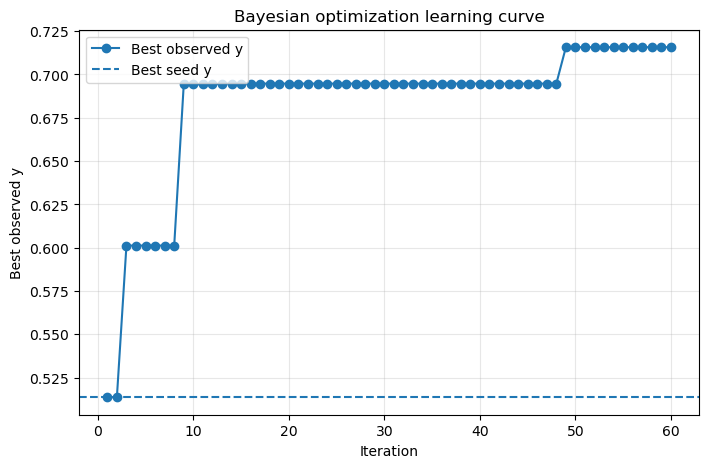

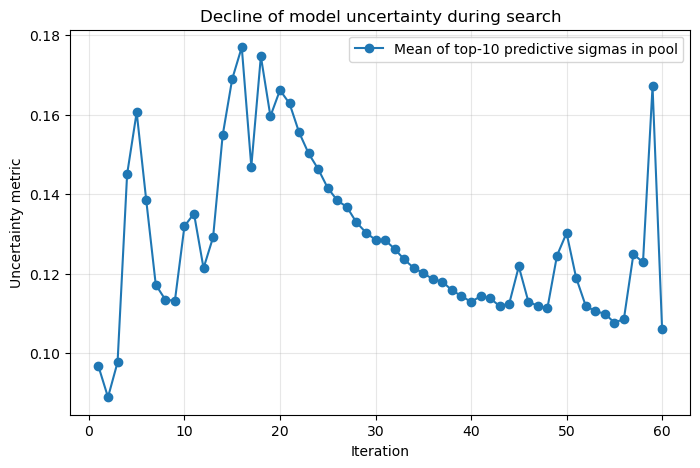

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
  history_df["iteration"],
  history_df["best_observed_y"],
  marker="o",
  label="Best observed y"
)
ax.axhline(
  y.loc[SEED_INDICES].max(),
  linestyle="--",
  label="Best seed y"
)
ax.set_xlabel("Iteration")
ax.set_ylabel("Best observed y")
ax.set_title("Bayesian optimization learning curve")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
  history_df["iteration"],
  history_df["mean_top10_sigma_pool"],
  marker="o",
  label="Mean of top-10 predictive sigmas in pool"
)
ax.set_xlabel("Iteration")
ax.set_ylabel("Uncertainty metric")
ax.set_title("Decline of model uncertainty during search")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

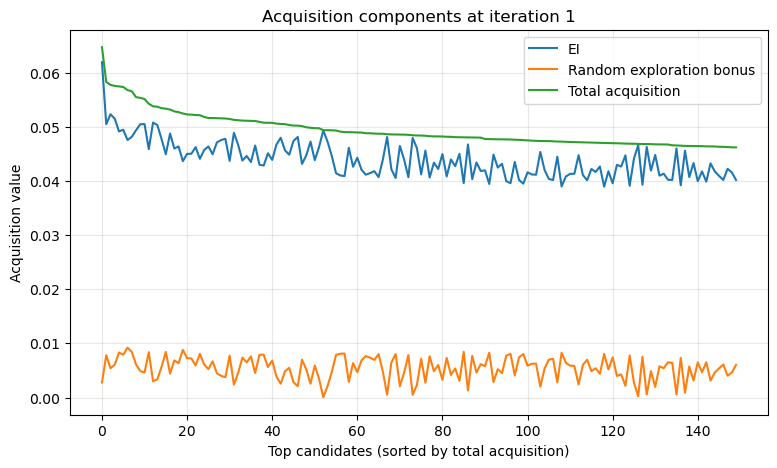

,index,mu,sigma,EI,random_bonus,acquisition
0,13069,0.559235,0.104714,0.061902,0.002769,0.064672
1,6959,0.546964,0.094513,0.050452,0.007817,0.058269
2,6958,0.550334,0.094030,0.052302,0.005408,0.057711
3,6944,0.562027,0.070953,0.051476,0.006059,0.057535
4,6946,0.551357,0.084010,0.049121,0.008318,0.057439
5,6945,0.553593,0.081051,0.049433,0.007902,0.057334
6,6908,0.541304,0.095547,0.047544,0.009212,0.056757
7,6936,0.545535,0.090694,0.048121,0.008434,0.056556
8,6949,0.551766,0.083927,0.049348,0.006107,0.055454
9,6954,0.554128,0.082865,0.050453,0.004873,0.055326


In [20]:
def plot_acquisition_components_at_iteration(
  iteration_number,
  history_df,
  X_scaled,
  y,
  seed_indices,
  xi=0.01,
  random_weight=0.10,
  random_state=238
):
  rng = np.random.default_rng(random_state)

  observed = list(seed_indices)

  # replay the same selections up to the requested iteration - 1
  for k in range(iteration_number - 1):
    observed.append(int(history_df.loc[k, "selected_index"]))

  unobserved = list(X_scaled.index.difference(observed))

  gp = make_gp(random_state=random_state)
  gp.fit(X_scaled.loc[observed].values, y.loc[observed].values)

  mu_pool, sigma_pool = gp.predict(X_scaled.loc[unobserved].values, return_std=True)
  best_y = float(y.loc[observed].max())

  acquisition, ei_pool, rand_bonus_pool, rand_draw_pool = mixed_ei_acquisition(
    mu=mu_pool,
    sigma=sigma_pool,
    best_y=best_y,
    rng=rng,
    xi=xi,
    random_weight=random_weight
  )

  order = np.argsort(acquisition)[::-1][:150]

  fig, ax = plt.subplots(figsize=(9, 5))
  ax.plot(ei_pool[order], label="EI")
  ax.plot(rand_bonus_pool[order], label="Random exploration bonus")
  ax.plot(acquisition[order], label="Total acquisition")
  ax.set_xlabel("Top candidates (sorted by total acquisition)")
  ax.set_ylabel("Acquisition value")
  ax.set_title(f"Acquisition components at iteration {iteration_number}")
  ax.legend()
  ax.grid(True, alpha=0.3)
  plt.show()

  top_df = pd.DataFrame({
    "index": np.array(unobserved)[order],
    "mu": mu_pool[order],
    "sigma": sigma_pool[order],
    "EI": ei_pool[order],
    "random_bonus": rand_bonus_pool[order],
    "acquisition": acquisition[order]
  })

  return top_df

top_candidates_iter1 = plot_acquisition_components_at_iteration(
  iteration_number=1,
  history_df=history_df,
  X_scaled=X_scaled,
  y=y,
  seed_indices=SEED_INDICES,
  xi=XI,
  random_weight=RANDOM_WEIGHT,
  random_state=238
)

display(top_candidates_iter1.head(10))

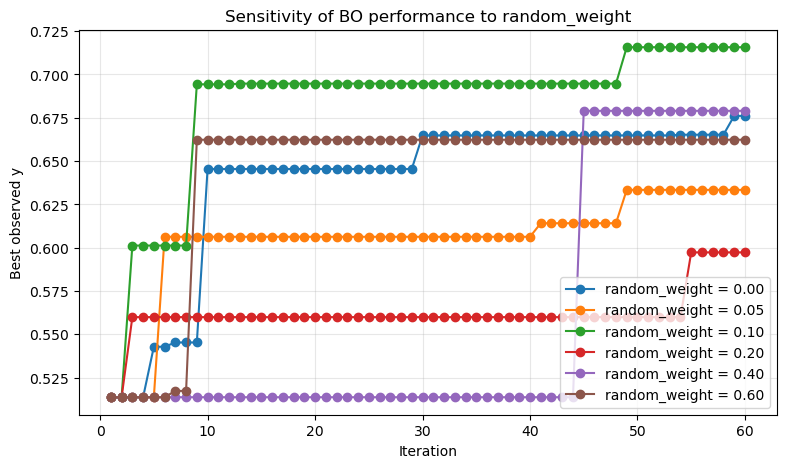

,random_weight,best_y_after_20_iters,iterations_run
2,0.10,0.715717,60
4,0.40,0.679018,60
0,0.00,0.676102,60
5,0.60,0.662332,60
1,0.05,0.633405,60
3,0.20,0.597317,60


In [23]:
def run_for_weight(random_weight, xi=0.01, n_iter=20, random_state=238):
  history_tmp, _, _, _ = run_bayesian_optimization(
    X_scaled=X_scaled,
    y=y,
    seed_indices=SEED_INDICES,
    n_iter=n_iter,
    xi=xi,
    random_weight=random_weight,
    random_state=random_state,
    patience=999,
    sigma_tol=0.0
  )
  return history_tmp

weights_to_test = [0.00, 0.05, 0.10, 0.20, 0.40, 0.60]

fig, ax = plt.subplots(figsize=(9, 5))

weight_summary = []

for w in weights_to_test:
  hist_w = run_for_weight(random_weight=w, xi=XI, n_iter=60, random_state=238)
  ax.plot(
    hist_w["iteration"],
    hist_w["best_observed_y"],
    marker="o",
    label=f"random_weight = {w:.2f}"
  )

  weight_summary.append({
    "random_weight": w,
    "best_y_after_20_iters": hist_w["best_observed_y"].iloc[-1],
    "iterations_run": len(hist_w)
  })

ax.set_xlabel("Iteration")
ax.set_ylabel("Best observed y")
ax.set_title("Sensitivity of BO performance to random_weight")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

weight_summary_df = pd.DataFrame(weight_summary).sort_values("best_y_after_20_iters", ascending=False)
display(weight_summary_df)

In [22]:
best_row_idx = int(history_df["best_observed_y"].idxmax())
best_found_index = int(history_df.loc[best_row_idx, "selected_index"])
best_found_y = float(y.loc[best_found_index])

print(f"Best structure found by BO: index {best_found_index}")
print(f"Best y found by BO: {best_found_y:.6f}")

best_structure = df.loc[[best_found_index]].copy()
display(best_structure)

print("Final optimized kernel:")
print(gp_final.kernel_)

# optional: compare to the true global optimum only after the BO campaign is complete
true_best_index = int(y.idxmax())
true_best_y = float(y.max())

print(f"True global optimum in full dataset: index {true_best_index}, y = {true_best_y:.6f}")
print(f"Gap to global optimum: {true_best_y - best_found_y:.6f}")

Best structure found by BO: index 10050
Best y found by BO: 0.715717


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,y
10050,26.37239,0.116326,0.957992,-0.217596,0.177761,1.648478,0.123522,0.033044,28.1386,0.841775,2.8922,0.715717


Final optimized kernel:
0.73**2 * Matern(length_scale=[100, 3.22, 100, 2.58, 0.807, 100, 100, 100, 0.639, 100, 1.29], nu=1.5) + WhiteKernel(noise_level=9.97e-07)
True global optimum in full dataset: index 10786, y = 0.752099
Gap to global optimum: 0.036382
